### SVM_Classification_(Linear)

Step 1: Data Load လုပ်ခြင်းနှင့် Feature များ သီးခြားခွဲထုတ်ခြင်း (Data Loading & Feature Selection)
-   Machine Learning Model မတည်ဆောက်မီ လိုအပ်တဲ့ Dataset ကို ဖတ်ယူပြီး၊ ခန့်မှန်းတွက်ချက်မယ့် အချက်အလက် (Features) နဲ့ အဖြေ (Target) ကို သီးခြားစီ ခွဲထုတ်လိုက်ခြင်း ဖြစ်ပါတယ်။

In [81]:
import pandas as pd

df = pd.read_csv("train.csv")

# Choose 2 numeric features only
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
x = df[['Age', 'Sex']]
y = df['Survived']

# Fill missing values
x = x.fillna(x.mean())

Step 2: Data ကို အုပ်စုခွဲခြင်း (Train/Test Split)

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

Step 3: အချက်အလက်များကို စံသတ်မှတ်ချက်အတွင်း ညှိယူခြင်း (Feature Scaling)
-   SVM Algorithm သည် Data များ၏ အကွာအဝေး (Distance) ပေါ်မူတည်၍ အလုပ်လုပ်သောကြောင့် ယူနစ်မတူညီသော Data များကို စံနှုန်းတစ်ခုတည်းဖြစ်အောင် ညှိယူပေးခြင်း ဖြစ်ပါတယ်။

In [83]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Step 4: Linear SVM Model တည်ဆောက်ခြင်းနှင့် Training ပေးခြင်း (Model Building & Training)
-   Hyperparameter C=2.0: 'C' သည် Regularization parameter ဖြစ်ပါတယ်။ (C တန်ဖိုးကို ကစားကြည့်ပါ။)
-   ဤတန်ဖိုးက Model ကို "မှားယွင်းမှု ဘယ်လောက် လက်ခံမလဲ" ဆိုတာကို ထိန်းချုပ်ပေးပါတယ်။

In [84]:
from sklearn.svm import SVC

# Linear SVM Model တည်ဆောက်ခြင်း
linear_model = SVC(kernel='linear', C=2.0) 
linear_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",2.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Step 5: Model ၏ တိကျမှုကို စစ်ဆေးခြင်း (Model Evaluation)
-   ယခုအဆင့်မှာတော့ Model ကို မမြင်ဖူးသေးတဲ့ Test Data တွေပေးပြီး ခန့်မှန်းခိုင်းမှာဖြစ်ပြီး၊ ထွက်ပေါ်လာတဲ့ အဖြေတွေဟာ တကယ်တမ်း ရှိနေတဲ့ အဖြေမှန်တွေနဲ့ ဘယ်လောက်အထိ ကိုက်ညီမှုရှိလဲဆိုတာကို ရာခိုင်နှုန်းနဲ့ တွက်ချက်စစ်ဆေးမှာ ဖြစ်ပါတယ်။

In [85]:
from sklearn.metrics import accuracy_score

# ရလဒ်ထုတ်ကြည့်ခြင်း
y_pred = linear_model.predict(X_test)
print("--- Linear SVM Result ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

--- Linear SVM Result ---
Accuracy Score: 78.21%



Step 6: အရေးပါသော အချက်အလက်များကို ရှာဖွေခြင်းနှင့် ပုံဖော်ခြင်း (Feature Importance & Visualization)
-   Linear SVM Model ရဲ့ ဆုံးဖြတ်ချက်အပေါ်မှာ ဘယ် Feature (ဥပမာ - အသက်၊ ရင်ဘတ်အောင့်ခြင်း) တွေက အကျိုးသက်ရောက်မှု အရှိဆုံးလဲဆိုတာကို Coefficients တန်ဖိုးတွေကတစ်ဆင့် တွက်ချက်ကြည့်ခြင်း ဖြစ်ပါတယ်။

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19068\1219968729.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


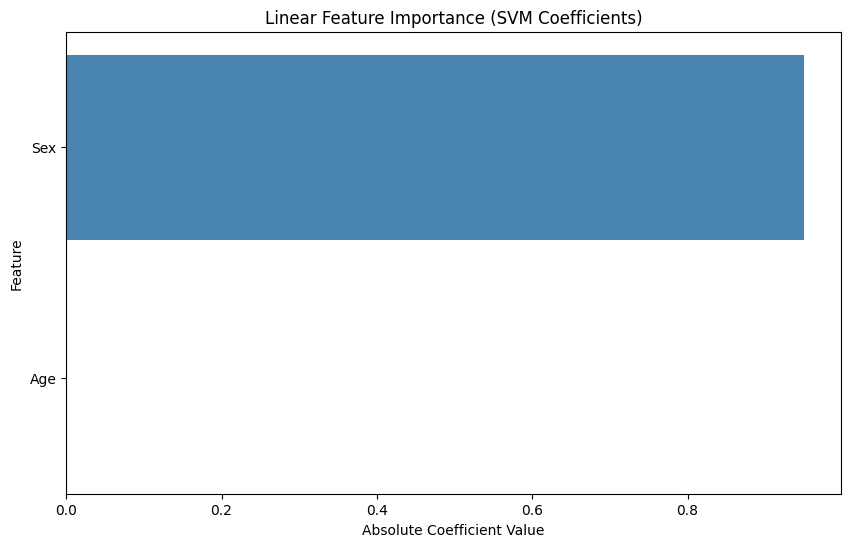

In [86]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

linear_importance = np.abs(linear_model.coef_[0])
feat_importance = pd.DataFrame({'Feature': x.columns, 'Importance': linear_importance})
feat_importance = feat_importance.sort_values(by='Importance', ascending=False)

# Visualization 
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feat_importance, 
    # hue='Feature', 
    palette='Blues_r', 
    # legend=True
)

plt.title('Linear Feature Importance (SVM Coefficients)')
plt.xlabel('Absolute Coefficient Value')
plt.show()

Step 7: အချက်အလက်များ၏ အရေးပါမှုကို ဇယားဖြင့် အသေးစိတ်ကြည့်ရှုခြင်း (Feature Importance Table)

In [87]:
# ဇယားပုံစံဖြင့် ထုတ်ပြခြင်း
print("--- Feature Importance Table ---")
print(feat_importance)

--- Feature Importance Table ---
  Feature  Importance
1     Sex    0.950164
0     Age    0.000007


### Data Visualization for SVM (Linear)

- ယခုအဆင့်မှာတော့ နှလုံးရောဂါ ရှိ၊ မရှိ ခွဲခြားဖို့အတွက် အရေးကြီးတဲ့ Feature နှစ်ခုဖြစ်တဲ့ cp (ရင်ဘတ်အောင့်ခြင်းအမျိုးအစား) နဲ့ oldpeak (လေ့ကျင့်ခန်းလုပ်ချိန်တွင် ဖြစ်ပေါ်သော ST depression) ကို အသုံးပြုပြီး Support Vector Classifier (SVC) ကို train မှာဖြစ်ပါတယ်။

In [92]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# CSV ဖိုင်ကို ဖတ်ခြင်း
df = pd.read_csv('train.csv')
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
# Visualization အတွက် Feature ၂ ခုသာ ရွေးချယ်ခြင်းနှင့် Scaling လုပ်ခြင်း
X_vis = df[['Age','Sex']].copy()
X_vis['Age'] = X_vis['Age'].fillna(X_vis['Age'].mean())  # replace NaN with mean
y_vis = df['Survived'].values
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_vis)

# Linear SVM Model ကို တည်ဆောက်ပြီး Training ပေးခြင်း
model = SVC(kernel='linear', C=2.0)
model.fit(X_scaled, y_vis)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",2.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


- Model က Data တွေကို ဘယ်လို ခွဲခြားထားသလဲဆိုတာကို Graph ပေါ်မှာ အရောင်ခြယ်ပြီး ပြသနိုင်ဖို့အတွက် ကျွန်တော်တို့ဟာ Graph တစ်ခုလုံးအနှံ့ အမှတ်အစက်ကလေးပေါင်းများစွာ (Fine Grid) ကို ဖန်တီးရမှာ ဖြစ်ပါတယ်။

In [94]:
import numpy as np

# မျက်နှာပြင်အတွက် အစက်အပြောက်များ တည်ဆောက်ခြင်း
h = .02  # အစက်အပြောက်များ၏ အကွာအဝေး (Mesh step size)
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Grid တစ်ခုလုံးပေါ်ရှိ အမှတ်များအတွက် ခန့်မှန်းချက်ထုတ်ခြင်း
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# display(Z)

- ယခုအဆင့်မှာတော့ ကျွန်တော်တို့ တည်ဆောက်ခဲ့တဲ့ Model က Data အုပ်စုနှစ်ခုကြားမှာ ဘယ်လိုမျဉ်းကြောင်းမျိုးနဲ့ ခွဲခြားထားသလဲ၊ ဘယ်အမှတ်တွေကို Support Vectors တွေအဖြစ် သတ်မှတ်ထားသလဲဆိုတာကို Graph ပေါ်မှာ ဖော်ပြမှာ ဖြစ်ပါတယ်။

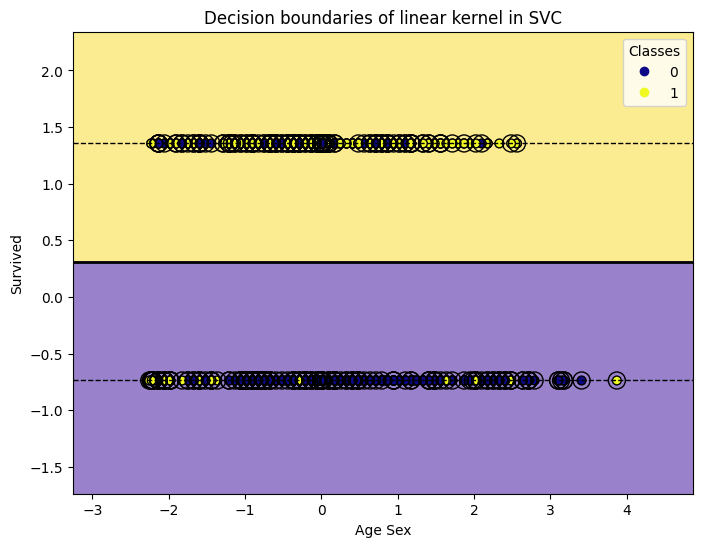

In [96]:
import matplotlib.pyplot as plt

# Plot ဆွဲခြင်း
plt.figure(figsize=(8, 6))

# နောက်ခံကို အရောင်ခြယ်ခြင်း (Decision Regions)
plt.contourf(xx, yy, Z, cmap='plasma', alpha=0.5)

# အလယ်မျဉ်း (Boundary) နဲ့  Margins မျဉ်းတွေကို ဆွဲခြင်း
P = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contour(xx, yy, P, colors='black', levels=[-1, 0, 1], alpha=1.0,
            linestyles=['--', '-', '--'], linewidths=[1, 2, 1])

# လူနာတွေရဲ့ ဒေတာအစက်လေးတွေကို ချခြင်း
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_vis, s=40, 
                      cmap='plasma', edgecolors='k', label='Data Points')

# မျဉ်းကြောင်းကို အဓိက ထိန်းချုပ်နေတဲ့ Support Vectors အစက်တွေကို အဝိုင်းဝိုင်းပြခြင်း
plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=150,
            linewidth=1, facecolors='none', edgecolors='black', label='Support Vectors')

# ဝင်ရိုးအမည်များနှင့် ခေါင်းစဉ်များ တပ်ခြင်း
plt.xlabel('Age Sex')
plt.ylabel('Survived')
plt.title('Decision boundaries of linear kernel in SVC')
plt.legend(*scatter.legend_elements(), title="Classes", loc="upper right")
plt.show()